**Aufgabe 2.a**

In dieser Teilaufgabe schreiben wir das System der GDLen vom Hodgkin-Huxley-Model und implementieren das Euler-Verfahren, um dieses System für Zeitraum $t0 = 50$ ms und konstanten Strom $I = I_0 = 10$ nA. Für die Teilaufgabe verwendeten Module finden Sie in “aufgabe2.ode_solver_euler.py”, dass “aufgabe2.equations.py” aufruft, um wie Gleichungen geschrieben sind. “equations.py” kann mit Zustandsvektor des Systems für einen Neron sowie mit Zustandsmatrix umgehen, was später in Aufgabe 3 verwendet wird.

Es ist zu merken, dass $\alpha_n$ und $\alpha_m$ bei den Werten $V_0 = -55$ mV bzw. $V_0 = -40$ mV die Unbestimmte Form $\frac{0}{0}$ haben. Dementsprechend ist es sinnvoll neben diesen Punkten für numerische Stabilität die Taylor-Entwicklung anzuwenden. Es gilt:
$$\alpha = -c\frac{V_0 + V}{e^{-(V_0 + V)/10} - 1} = 10c \frac{x}{e^x - 1} = 10c (1- \frac{x}{2} + \frac{x^2}{12} + O(x^3))$$
mit
$$x = -\frac{V_0 + V}{10}$$

Um die Gleichgewichtswerte für die Gating-Variablen $n_\infty, m_\infty, h_\infty$ setzen wir den Wert $V = -65$ mV in die Gleichung (16) aus der Aufgabe 1.a ein. Dann gilt es:
$$n_\infty = \alpha(V_{pot}) = \frac{\alpha(V_{pot}}{\alpha(V_{pot} + \beta(V_{pot}} \approx 0.3177$$
$$m_\infty \approx  0.0529 $$
$$h_\infty \approx 0.5961$$

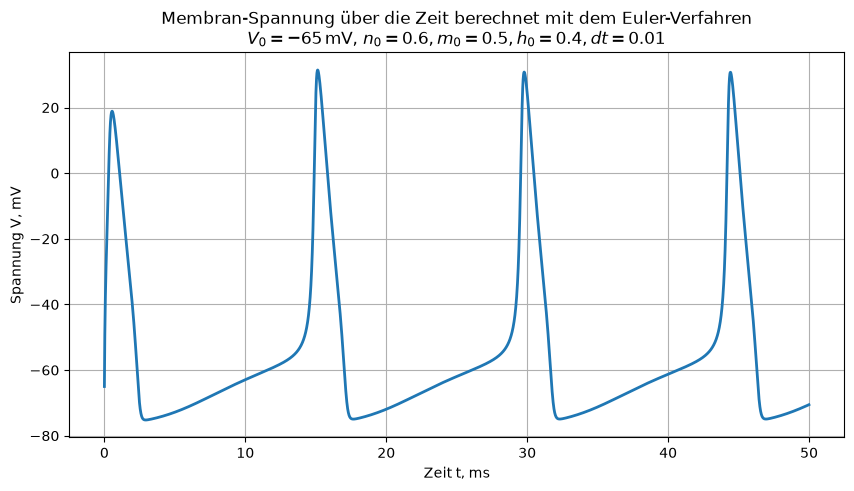

In [1]:

from aufgabe2.ode_solver_euler import euler_method
import matplotlib.pyplot as plt
import numpy as np

V_0 = -65
n_0 = 0.6
m_0 = 0.5
h_0 = 0.4
x = np.array([V_0,n_0, m_0, h_0])
tuple_of_constants = (1, 36, 120, 0.3, -77, 50, -54.387)

t_a = 0
t_b = 50
dt = 0.01

I_0 = 10
I = lambda t: I_0
v = euler_method(x, t_a, t_b, dt, I, tuple_of_constants) [0: ,0]
tpoints = np.arange(0, 50, dt)
plt.figure(figsize=(10, 5))
plt.plot(tpoints,v, linewidth=2)
plt.title(
    "Membran-Spannung über die Zeit berechnet mit dem Euler-Verfahren\n"
    + rf"$V_0 = {V_0}\,$mV, $n_0 = {n_0}, m_0 = {m_0}, h_0 = {h_0}, dt = {dt}$"
)
plt.xlabel("Zeit t, ms")
plt.ylabel("Spannung V, mV")
plt.grid(True)
plt.show()


**Aufgabe 2.b**

Nun implementieren wir das Runge-Kutta-Verfahren des 4. Grads. Der Code befindet sich in 'aufgabe2.ode_solver_runge_kutta'.

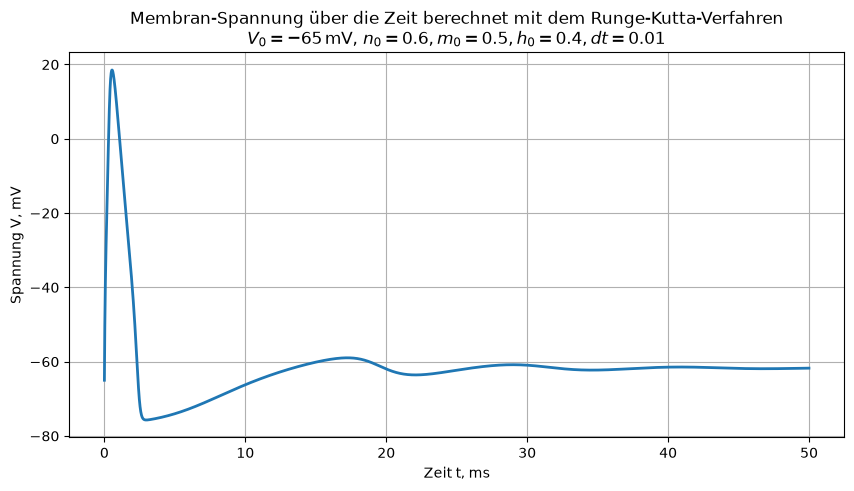

In [5]:
from aufgabe2.ode_solver_runge_kutta import runge_kutta_method


v = runge_kutta_method(x, t_a, t_b, dt, I, tuple_of_constants) [0: ,0]
plt.figure(figsize=(10, 5))
plt.plot(tpoints,v, linewidth=2)
plt.title(
    "Membran-Spannung über die Zeit berechnet mit dem Runge-Kutta-Verfahren\n"
    + rf"$V_0 = {V_0}\,$mV, $n_0 = {n_0}, m_0 = {m_0}, h_0 = {h_0}, dt = {dt}$"
)
plt.xlabel("Zeit t, ms")
plt.ylabel("Spannung V, mV")
plt.grid(True)
plt.show()

Eben lösen wir das Gleihungssystem mit 'scipy.odeint'. Alle drei Verfahren liefern visuel ähnliche Resultate für Zeitschritt $dt = 0.01$ ms.

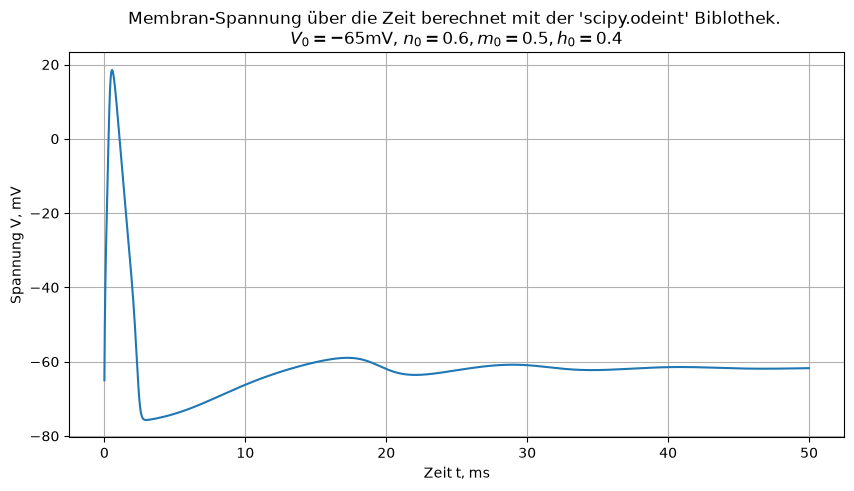

In [7]:
import scipy.integrate as spi
import aufgabe2.equations as eq
state_0 = [-65, 0.6, 0.5, 0.4]

I = 5

def hh_system(state, t, I, tuple_of_constants : tuple[float]):
    return eq.equations_vector(state, I, tuple_of_constants)

solution = spi.odeint(hh_system, state_0, tpoints, args=(I,tuple_of_constants) )

V_t = solution[:, 0]


# --- Plot ---
plt.figure(figsize=(10, 5))
plt.plot(tpoints, V_t)
plt.title("Membran-Spannung über die Zeit berechnet mit der 'scipy.odeint'-Biblothek. \n" + rf"$V_0 = {V_0}$mV, $n_0 = {n_0}, m_0 = {m_0}, h_0 = {h_0}$")
plt.xlabel("Zeit t, ms")
plt.ylabel("Spannung V, mV")
plt.grid(True)
plt.show()

**Aufgabe 2.c**

Wie rechne den Verlauf der Spannung für Stromwerte von -5 bis zu 15 nA. Es fällt uns auf, dass in ersten ca.3 mS alle Stromstärken Spannungsausschlag verursachen, bleibt das Neuron danach im Ruhezustand nur für Strom $I \in [-5,5]$. Weiterhing steigt die Frequenz der Spannung mit Strom.

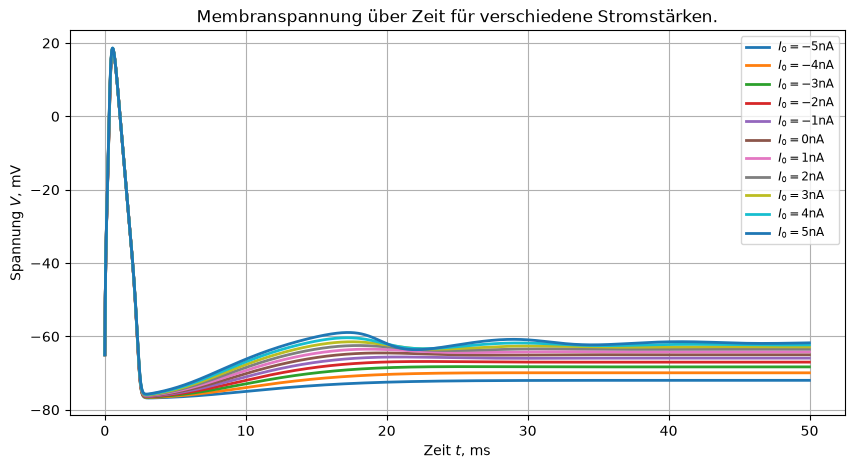

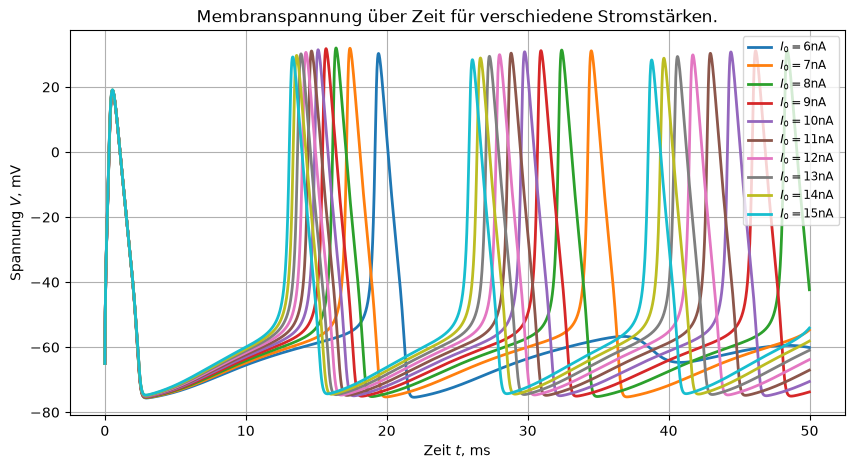

In [13]:
plt.figure(figsize=(10, 5))

current_values = list(range(-5, 6))
tpoints = np.arange(t_a, t_b, dt)

for i in current_values:
    I_func = lambda t, val=i: val
    temp = euler_method(x, t_a, t_b, dt, I_func, tuple_of_constants)[0:, 0]
    plt.plot(tpoints, temp, linewidth=2, label=f"$I_0 = {i}$nA")


plt.xlabel("Zeit $t$, ms")
plt.ylabel("Spannung $V$, mV")
plt.title("Membranspannung über Zeit für verschiedene Stromstärken.")
plt.grid(True)


plt.legend(loc="upper right", fontsize="small")

#another plot
plt.figure(figsize=(10, 5))

current_values = list(range(6, 16))
tpoints = np.arange(t_a, t_b, dt)

for i in current_values:
    I_func = lambda t, val=i: val
    temp = euler_method(x, t_a, t_b, dt, I_func, tuple_of_constants)[0:, 0]
    plt.plot(tpoints, temp, linewidth=2, label=f"$I_0 = {i}$nA")


plt.xlabel("Zeit $t$, ms")
plt.ylabel("Spannung $V$, mV")
plt.title("Membranspannung über Zeit für verschiedene Stromstärken.")
plt.grid(True)


plt.legend(loc="upper right", fontsize="small")


plt.show()


**Aufgabe 2.d**

In unteren Zeile befinden sich die graphische Darstellungen von $U, I, n, m, h$ im Zeitraum von 50 ms. Der Stromimpuls ist gegen durch:
$$
I = \begin{cases}
      50 \text{ nA} &, \ t \in [10,11] \\
      4 \text{ nA} &, \ \text{sonst} \\
   \end{cases}
$$
Dieser Impuls verursacht rasche Steigung der Spannung $V$ und der Gating-Variablen$n, m, h$. Nach dem Impuls erreicht das System wieder den Ruhezustand. Die Gating-Variablen erreichen ihren terminalen Zustand, wie es in der Aufgabe 1.a vorhergesagt wurde.

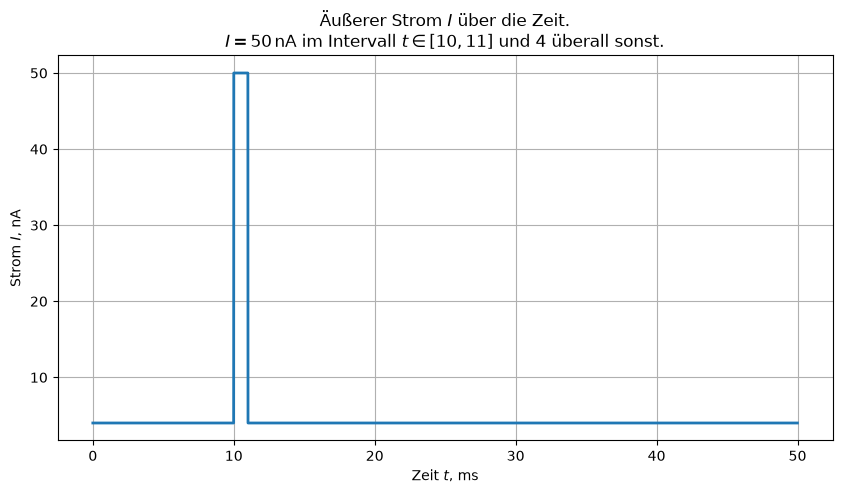

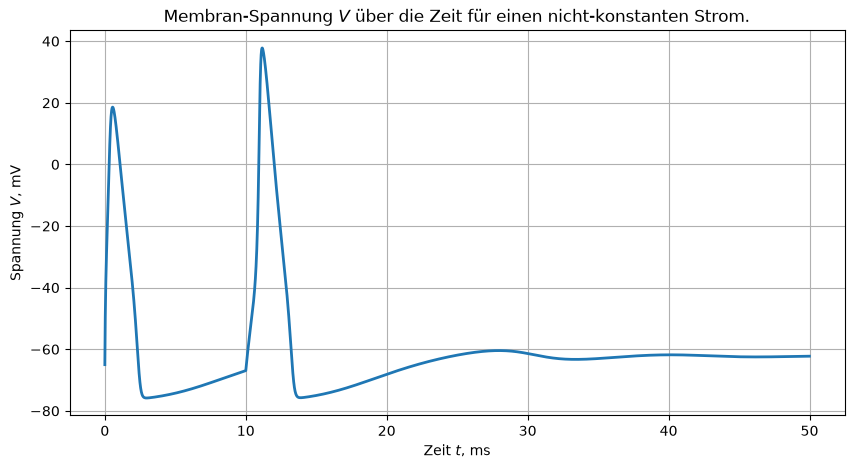

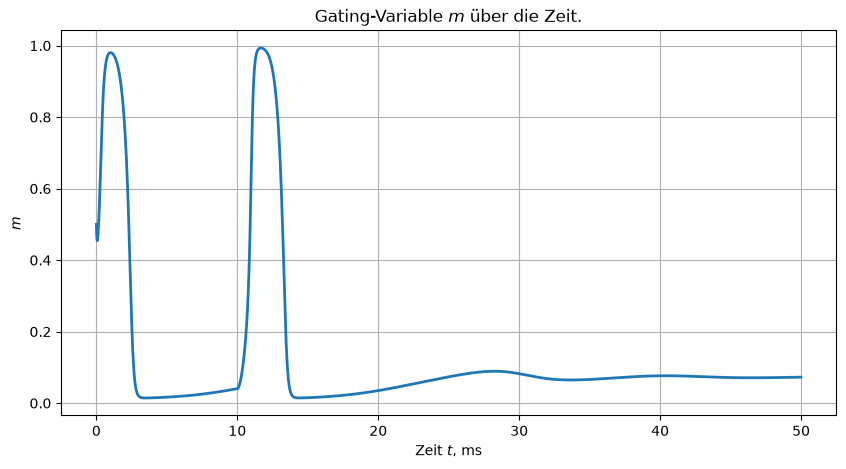

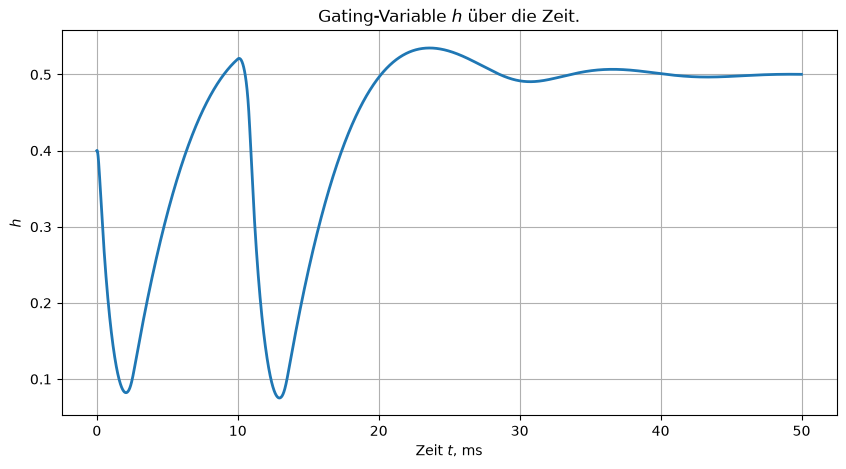

In [3]:
I_0 = 4
I_func = lambda t: 50 if (10 <= t <= 11) else I_0
I_values = np.array([I_func(t) for t in tpoints])
s = euler_method(x, t_a, t_b, dt, I_func, tuple_of_constants)
v = s[0: ,0]
n = s[0: ,1]
m = s[0: ,2]
h = s[0: ,3]
tpoints = np.arange(0, 50, dt)

plt.figure(figsize=(10, 5))
plt.plot(tpoints, I_values, linewidth=2)
plt.xlabel("Zeit $t$, ms")
plt.ylabel("Strom $I$, nA")  # Korrigiert von Spannung zu Strom (Einheit nA)
plt.title(
    "Äußerer Strom $I$ über die Zeit.\n"
    + rf"$I = 50\,$nA im Intervall $t \in [10,11]$ und {I_0} überall sonst."
)
plt.grid(True)


plt.figure(figsize=(10, 5))
plt.plot(tpoints, v, linewidth=2)
plt.xlabel("Zeit $t$, ms")
plt.ylabel("Spannung $V$, mV")
plt.title("Membran-Spannung $V$ über die Zeit für einen nicht-konstanten Strom.")
plt.grid(True)

plt.figure(figsize=(10, 5))
plt.plot(tpoints, m, linewidth=2)
plt.xlabel("Zeit $t$, ms")
plt.ylabel("$m$")
plt.title("Gating-Variable $m$ über die Zeit.")
plt.grid(True)

plt.figure(figsize=(10, 5))
plt.plot(tpoints, h, linewidth=2)
plt.xlabel("Zeit $t$, ms")
plt.ylabel("$h$")
plt.title("Gating-Variable $h$ über die Zeit.")
plt.grid(True)



plt.show()
